In [1]:
import os, glob, shutil, zipfile, gdown
import random, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers, losses

import tensorboard as tb

# metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
#original Link
# https://drive.google.com/file/d/1XS6tyOR5oyKbKUSl52XK3XVndCQUZ1ps/view?usp=sharing

# Global Variables
FILE_ID = "1XS6tyOR5oyKbKUSl52XK3XVndCQUZ1ps"
tf.keras.utils.set_random_seed(200)
height, width = 224, 224
BATCH_SIZE=128
channels = 3

In [3]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")

    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

In [4]:
def download_and_prep_dataset(FILE_ID):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "dataSet/New_landmark_images.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)

    # Load the dataset
    data_path = os.path.join(extractPath, "New_landmark_images")
    return data_path

def preprocess(train_data, val_data, test_data, target_height=128, target_width=128):

    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = keras.Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255),
        ]
    )

    # Perform Data Processing on the train, val, test dataset
    train_ds = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [5]:
# prepare the Dataset
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)
print(dl_ext_data_path)

# Check the dataset Paths
train_path = os.path.join(dl_ext_data_path, "train")
test_path = os.path.join(dl_ext_data_path, "test")
val_path = os.path.join(dl_ext_data_path, "validation")

assert os.path.exists(train_path), "Train path does not exist"
assert os.path.exists(test_path), "Test path does not exist"
assert os.path.exists(val_path), "Val path does not exist"

# Load the dataset
Train_DS = tf.keras.utils.image_dataset_from_directory(directory=train_path, shuffle=True, label_mode="categorical", batch_size=BATCH_SIZE)
Test_DS = tf.keras.utils.image_dataset_from_directory(directory=test_path, shuffle=True, label_mode="categorical", batch_size=BATCH_SIZE)
Val_DS = tf.keras.utils.image_dataset_from_directory(directory=val_path, shuffle=True, label_mode="categorical", batch_size=BATCH_SIZE)

# Scale the DataSet
Train_scaled, Test_scaled, Val_scaled = preprocess(Train_DS, Val_DS, Test_DS, target_height=height, target_width=width)
classNames = Train_DS.class_names

CWD:  /content


Downloading...
From (original): https://drive.google.com/uc?id=1XS6tyOR5oyKbKUSl52XK3XVndCQUZ1ps
From (redirected): https://drive.google.com/uc?id=1XS6tyOR5oyKbKUSl52XK3XVndCQUZ1ps&confirm=t&uuid=0e718a8f-2474-4c7e-ad36-72d57f6a1d70
To: /content/dataSet/New_landmark_images.zip
100%|██████████| 112M/112M [00:01<00:00, 104MB/s]


Successfully downloaded to /content/dataSet/New_landmark_images.zip
Successfully extracted to /content/unzipLoc
/content/unzipLoc/New_landmark_images
Found 737 files belonging to 10 classes.
Found 43 files belonging to 10 classes.
Found 155 files belonging to 10 classes.


## Data Explotation

In [6]:
# dict to select one random image per class
imagePerClass = {}
# number of objects in each Class
countPerClass = {}

# list down all the classes in the folder
clsDirs = os.listdir(train_path)

for cls in clsDirs:
  # get list of all the images per each class
  imgPaths = glob.glob(train_path + f"/{cls}/*")

  # gives the number of images per class
  countPerClass[cls] = len(imgPaths)

  # randomly selects an image and saves it in a dictionary
  randomImage = random.choice(imgPaths)
  imagePerClass[cls] = tf.keras.utils.load_img(randomImage)

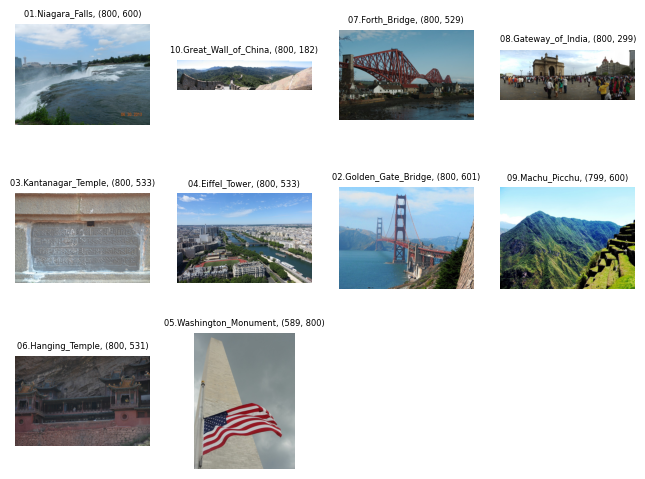

In [7]:
# display images
plt.figure(figsize=(8, 6))
for idx, (label, imgtoShow) in enumerate(imagePerClass.items()):
  # plot each Image
  ax = plt.subplot(3, 4, idx+1)
  plt.imshow(imgtoShow)
  plt.axis("off")
  plt.title(f"{label}, {imgtoShow.size}", fontsize=6)

Count of training samples per class:



Text(0, 0.5, 'Count')

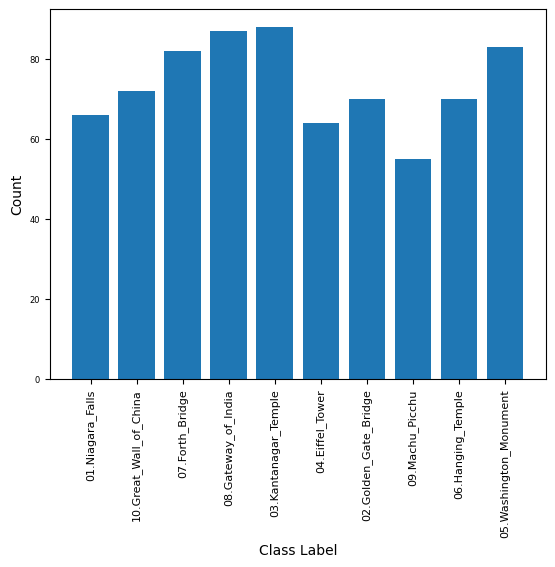

In [8]:
## Let's now Plot the Data Distribution of Training Data across Classes
print("Count of training samples per class:\n",)
countDataDist = pd.DataFrame({"label":countPerClass.keys(), "count":countPerClass.values()})
plt.bar(countDataDist["label"], countDataDist["count"])
plt.xlabel("Class Label", fontsize=10)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=6)
plt.ylabel("Count")

## Helper Functions

In [9]:
# start training the model
def start_model_training(model, train_data, val_data, epochs=15, model_name="CV_model",
                          useCSVLogger=False, useTensorBoard=False, modelChkpoint=False, earlyStopping=False, lrScheduler=False):

    logName = ""
    tensorBoardLogs = ""
    mdkCkhPointfilepath = ""

    model.compile(optimizer=optimizers.Adam(),
                loss=losses.CategoricalCrossentropy(),
                metrics=["accuracy"])
    callbackslist = []
    if useCSVLogger:
        logName = generate_logs_Name(fileName=model_name, logFormat=".log", clear_folder=False)
        csvLogger = callbacks.CSVLogger(filename=logName)
        callbackslist.append(csvLogger)

    if useTensorBoard:
        tensorBoardLogs = generate_logs_Folder(logfolderName=model_name+"_tb_logs", clear_folder=False)
        tensorBoard = callbacks.TensorBoard(log_dir=tensorBoardLogs, histogram_freq=1)
        callbackslist.append(tensorBoard)

    if modelChkpoint:
        modelChkpointLoc = generate_logs_Folder(logfolderName="model_save", clear_folder=False)
        mdkCkhPointfilepath = os.path.join(modelChkpointLoc, model_name+"_best_model.keras")
        modelCheckpoint = callbacks.ModelCheckpoint(filepath=mdkCkhPointfilepath,
                                                    save_best_only=True,
                                                    save_weights_only=False,
                                                    monitor="val_loss",
                                                    mode="min")
        callbackslist.append(modelCheckpoint)

    if earlyStopping:
        earlyStopping = callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max")
        callbackslist.append(earlyStopping)

    if lrScheduler:
        lrdecay = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=0.0001)
        callbackslist.append(lrdecay)

    # start the model Training
    history = model.fit(train_data,
                        validation_data=val_data,
                        epochs=epochs,
                        callbacks=callbackslist,
                        verbose=1)

    return history , (logName, tensorBoardLogs, mdkCkhPointfilepath)

In [10]:
def plot_training_history(history):
    trainAcc = history.history["accuracy"]
    valAcc = history.history["val_accuracy"]

    trainLoss = history.history["loss"]
    valLoss = history.history["val_loss"]

    # Plot the Training and Validation Accuracy
    plt.rcParams['legend.fontsize'] = 'x-small'
    fig, ax = plt.subplots(ncols=2, nrows=1)
    fig.set_figheight(4)
    fig.set_figwidth(8)
    ax[0].plot(trainAcc, label="Training Accuracy")
    ax[0].plot(valAcc, label="Validation Accuracy")
    ax[0].set_title("Training and Validation Accuracy")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")

    ax[0].legend()

    # Plot the Training and Validation Loss
    ax[1].plot(trainLoss, label="Training Loss")
    ax[1].plot(valLoss, label="Validation Loss")
    ax[1].set_title("Training and Validation Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.show()

In [11]:
# function to print the accuracy stats
def calculate_multiclass_metrics(model, test_ds, num_classes):
    """
    Calculate metrics for multi-class classification using sklearn metrics

    Args:
        model: Trained Keras model
        test_ds: Test dataset (tf.data.Dataset)
        num_classes: Number of classes
    Returns:
        Dictionary containing calculated metrics
    """
    # Get true labels and predictions
    y_true = []
    y_pred = []
    y_pred_proba = []

    # Collect predictions and true labels
    for x, y in test_ds:
        predictions = model.predict(x, verbose=0)
        y_true.append(tf.argmax(y, axis=1))
        y_pred.append(tf.argmax(predictions, axis=1))
        y_pred_proba.append(predictions)

    # Convert to numpy arrays
    y_true = tf.concat(y_true, axis=0).numpy()
    y_pred = tf.concat(y_pred, axis=0).numpy()
    y_pred_proba = tf.concat(y_pred_proba, axis=0).numpy()

    # Calculate metrics
    metrics_dict = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }

    # Print results
    print("\nTest Metrics:")
    print(f"Accuracy: {metrics_dict['accuracy']:.4f}")
    print(f"\nMacro-averaged metrics:")
    print(f"Precision: {metrics_dict['precision_macro']:.4f}")
    print(f"Recall: {metrics_dict['recall_macro']:.4f}")
    print(f"F1-score: {metrics_dict['f1_macro']:.4f}")

    print(f"\nWeighted-averaged metrics:")
    print(f"Precision: {metrics_dict['precision_weighted']:.4f}")
    print(f"Recall: {metrics_dict['recall_weighted']:.4f}")
    print(f"F1-score: {metrics_dict['f1_weighted']:.4f}")

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(metrics_dict['confusion_matrix'],
                annot=True,
                fmt='d',
                cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Plot ROC curves for each class
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.show()

    return metrics_dict

## Alex Net


In [12]:
# AlexNet
def AlexNet_Model(num_classes, model_name="CV_Model"):
  inpLayer = layers.Input(shape=(height, width, channels))
  conv2d_1 = layers.Conv2D(filters=96, kernel_size=(11, 11), strides=4, activation="relu", padding="same")(inpLayer)
  maxPool_1 = layers.MaxPool2D(pool_size=(3, 3), strides=2)(conv2d_1)

  conv2d_2 = layers.Conv2D(filters=256, kernel_size=(5, 5), strides=1, activation="relu", padding="same")(maxPool_1)
  maxPool_2 = layers.MaxPool2D(pool_size=(3, 3), strides=2)(conv2d_2)

  conv2d_3 = layers.Conv2D(filters=384, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(maxPool_2)
  conv2d_4 = layers.Conv2D(filters=384, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(conv2d_3)
  conv2d_5 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(conv2d_4)
  maxPool_3 = layers.MaxPool2D(pool_size=(3, 3), strides=2)(conv2d_5)
  flatten = layers.Flatten()(maxPool_3)
  dense_1 = layers.Dense(units=4096, activation="relu")(flatten)
  dropout_1 = layers.Dropout(0.5)(flatten)
  dense_2 = layers.Dense(units=4096, activation="relu")(dense_1)
  dropout_1 = layers.Dropout(0.5)(flatten)
  output = layers.Dense(units=num_classes, activation="softmax")(dense_2)

  return keras.Model(inputs=inpLayer, outputs=output, name=model_name)

In [13]:
modelName="AlexNet"

# create Model
alexNetModel = AlexNet_Model(num_classes=len(classNames) ,model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(alexNetModel, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=alexNetModel,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=40,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - accuracy: 0.0947 - loss: 5.1031 - val_accuracy: 0.1163 - val_loss: 2.3015 - learning_rate: 0.0010
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.1011 - loss: 2.3017 - val_accuracy: 0.0930 - val_loss: 2.3029 - learning_rate: 0.0010
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.1212 - loss: 2.2978 - val_accuracy: 0.0930 - val_loss: 2.3042 - learning_rate: 0.0010
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.0928 - loss: 2.2923 - val_accuracy: 0.1163 - val_loss: 2.3065 - learning_rate: 0.0010
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.1417 - loss: 2.2786 - val_accuracy: 0.1395 - val_loss: 2.2639 - learning_rate: 0.0010
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.1770 - loss: 2.3027 - val_accuracy: 0.1163 - val_loss: 2.3087 - learning_rate: 0.0010
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.1125 - loss: 2.2940 - val_accuracy: 0.0930 - val_l

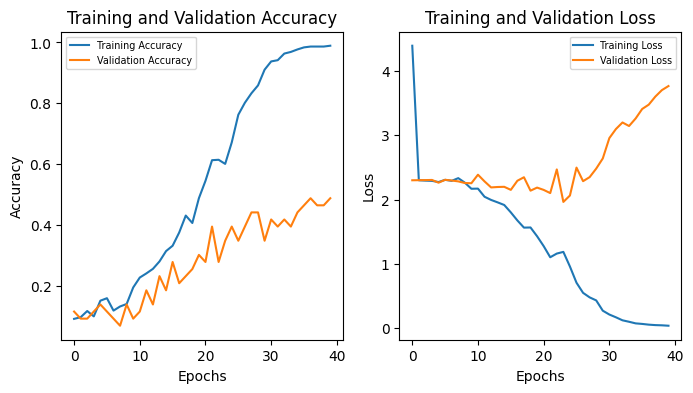

In [14]:
plot_training_history(history)


Test Metrics:
Accuracy: 0.4516

Macro-averaged metrics:
Precision: 0.4626
Recall: 0.4521
F1-score: 0.4455

Weighted-averaged metrics:
Precision: 0.4634
Recall: 0.4516
F1-score: 0.4455

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.50      0.52        16
           1       0.25      0.19      0.21        16
           2       0.62      0.62      0.62        16
           3       0.33      0.27      0.30        15
           4       0.45      0.62      0.53        16
           5       0.58      0.47      0.52        15
           6       0.29      0.47      0.36        15
           7       0.42      0.53      0.47        15
           8       0.57      0.25      0.35        16
           9       0.56      0.60      0.58        15

    accuracy                           0.45       155
   macro avg       0.46      0.45      0.45       155
weighted avg       0.46      0.45      0.45       155



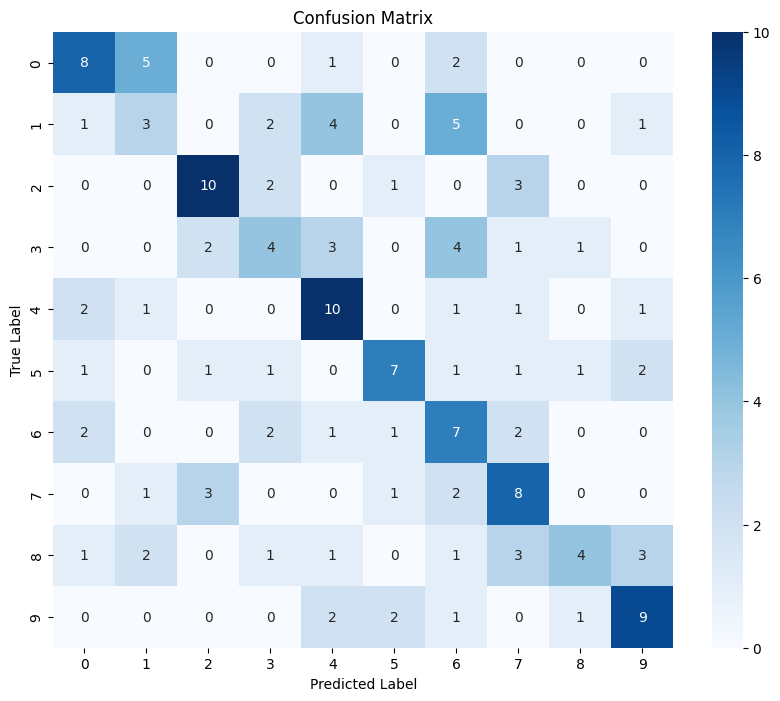

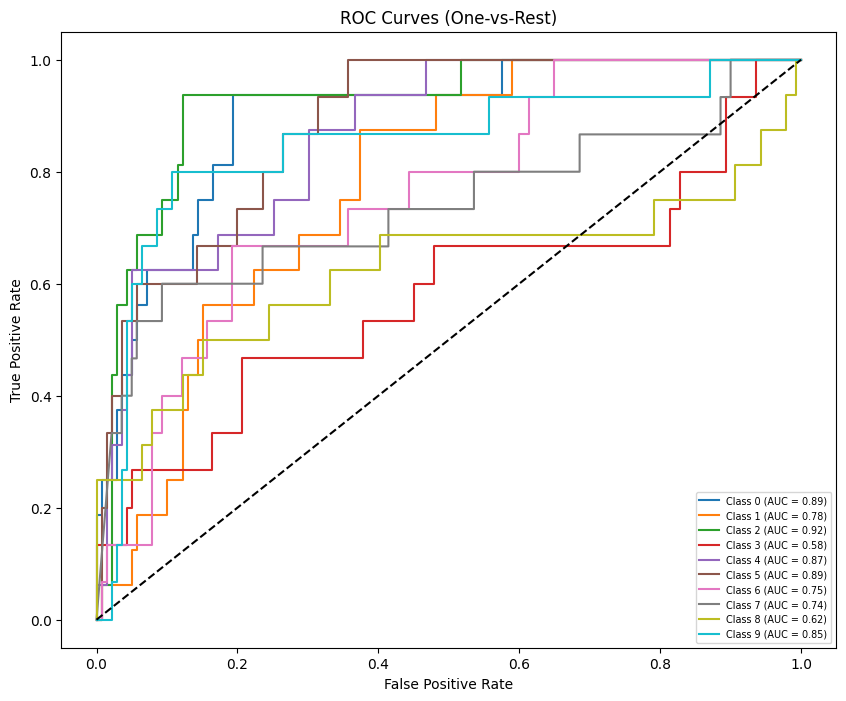

{'accuracy': 0.45161290322580644,
 'precision_macro': 0.462619332421964,
 'recall_macro': 0.4520833333333333,
 'f1_macro': 0.4454579193347599,
 'precision_weighted': 0.4634013369200126,
 'recall_weighted': 0.45161290322580644,
 'f1_weighted': 0.44547254531089014,
 'confusion_matrix': array([[ 8,  5,  0,  0,  1,  0,  2,  0,  0,  0],
        [ 1,  3,  0,  2,  4,  0,  5,  0,  0,  1],
        [ 0,  0, 10,  2,  0,  1,  0,  3,  0,  0],
        [ 0,  0,  2,  4,  3,  0,  4,  1,  1,  0],
        [ 2,  1,  0,  0, 10,  0,  1,  1,  0,  1],
        [ 1,  0,  1,  1,  0,  7,  1,  1,  1,  2],
        [ 2,  0,  0,  2,  1,  1,  7,  2,  0,  0],
        [ 0,  1,  3,  0,  0,  1,  2,  8,  0,  0],
        [ 1,  2,  0,  1,  1,  0,  1,  3,  4,  3],
        [ 0,  0,  0,  0,  2,  2,  1,  0,  1,  9]])}

In [15]:
calculate_multiclass_metrics(model=alexNetModel, test_ds=Test_scaled, num_classes=len(classNames))

No Keras pretrained AlexNet model

## VGG-16

In [16]:
# VGG-16
height = 224
width = 224
channels = 3

def VGG_16_Model(num_classes, model_name="CV_Model"):
  inpLayer = layers.Input(shape=(height, width, channels))

  conv2d_1 = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same")(inpLayer)
  conv2d_2 = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same")(conv2d_1)
  maxPool_1 = layers.MaxPool2D(pool_size=(2, 2), strides=2)(conv2d_2)

  conv2d_3 = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same")(maxPool_1)
  conv2d_4 = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same")(conv2d_3)
  maxPool_2 = layers.MaxPool2D(pool_size=(2, 2), strides=2)(conv2d_4)

  conv2d_5 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(maxPool_2)
  conv2d_6 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(conv2d_5)
  conv2d_7 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(conv2d_6)
  maxPool_3 = layers.MaxPool2D(pool_size=(2, 2), strides=2)(conv2d_7)

  conv2d_8 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(maxPool_3)
  conv2d_9 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(conv2d_8)
  conv2d_10 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=1, activation="relu", padding="same")(conv2d_9)
  maxPool_4 = layers.MaxPool2D(pool_size=(2, 2), strides=2)(conv2d_10)

  conv2d_11 = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding="same")(maxPool_4)
  conv2d_12 = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding="same")(conv2d_11)
  conv2d_13 = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding="same")(conv2d_12)
  maxPool_5 = layers.MaxPool2D(pool_size=(2, 2), strides=2)(conv2d_13)

  flatten = layers.Flatten()(maxPool_5)
  dense_1 = layers.Dense(units=4096, activation="relu")(flatten)
  dropout_1 = layers.Dropout(0.5)(flatten)
  # dense_2 = layers.Dense(units=4096, activation="relu")(dense_1)
  # dropout_1 = layers.Dropout(0.5)(flatten)
  output = layers.Dense(units=num_classes, activation="softmax")(dropout_1)

  return keras.Model(inputs=inpLayer, outputs=output, name=model_name)

In [18]:
modelName="Vgg_16_Net"

# create Model
vgg16NetModel = VGG_16_Model(num_classes=len(classNames) ,model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(vgg16NetModel, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=vgg16NetModel,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=40,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.0939 - loss: 2.3337 - val_accuracy: 0.1163 - val_loss: 2.3051 - learning_rate: 0.0010
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.1176 - loss: 2.2975 - val_accuracy: 0.1163 - val_loss: 2.3076 - learning_rate: 0.0010
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.1091 - loss: 2.2967 - val_accuracy: 0.1163 - val_loss: 2.3064 - learning_rate: 0.0010
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1249 - loss: 2.2983 - val_accuracy: 0.1163 - val_loss: 2.3097 - learning_rate: 0.0010
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1181 - loss: 2.2966 - val_accuracy: 0.1163 - val_loss: 2.3170 - learning_rate: 0.0010
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.1166 - loss: 2.2934 - val_accuracy: 0.0930 - val_loss: 2.3108 - learning_rate: 0.0010
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1146 - loss: 2.2955 - val_accuracy: 0.1163 - val_l

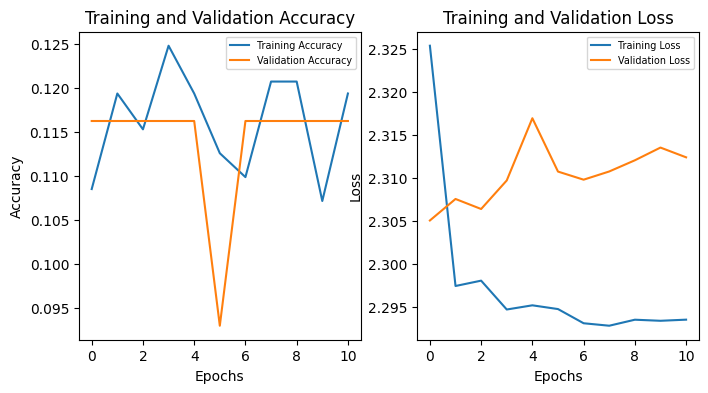

In [19]:
plot_training_history(history)


Test Metrics:
Accuracy: 0.1032

Macro-averaged metrics:
Precision: 0.0103
Recall: 0.1000
F1-score: 0.0187

Weighted-averaged metrics:
Precision: 0.0107
Recall: 0.1032
F1-score: 0.0193

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.00      0.00      0.00        16
           2       0.10      1.00      0.19        16
           3       0.00      0.00      0.00        15
           4       0.00      0.00      0.00        16
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00        15
           7       0.00      0.00      0.00        15
           8       0.00      0.00      0.00        16
           9       0.00      0.00      0.00        15

    accuracy                           0.10       155
   macro avg       0.01      0.10      0.02       155
weighted avg       0.01      0.10      0.02       155



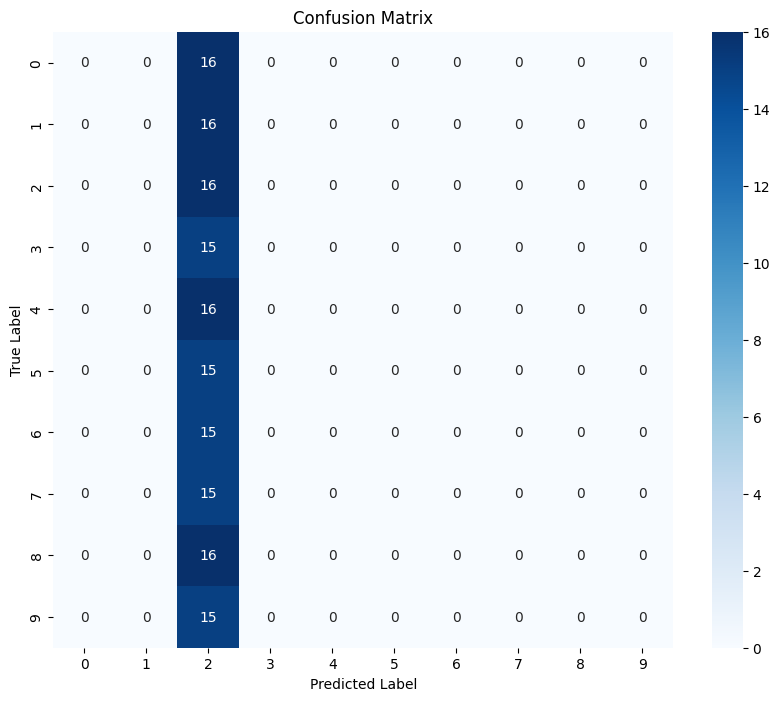

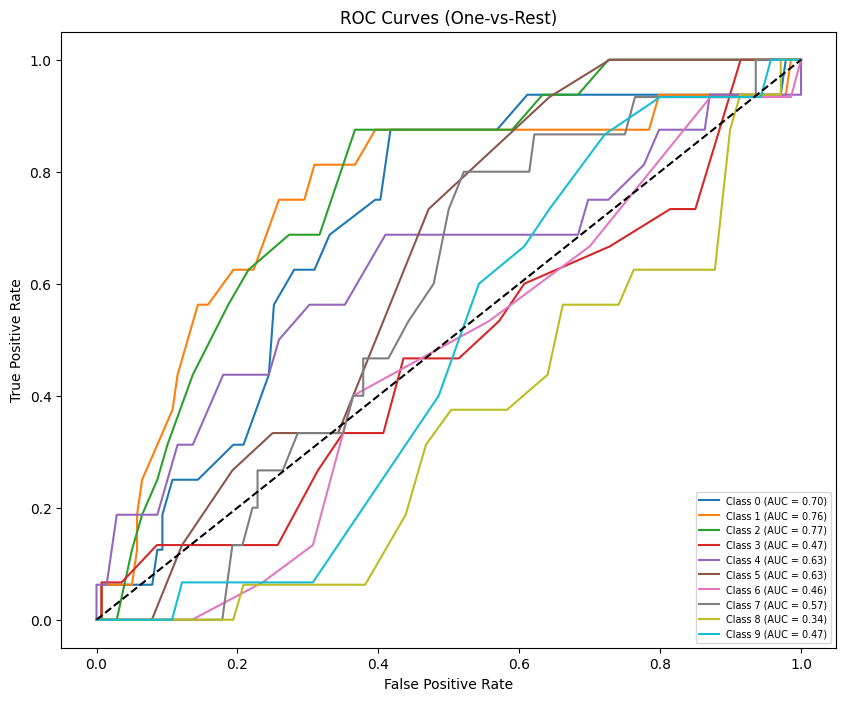

{'accuracy': 0.1032258064516129,
 'precision_macro': 0.01032258064516129,
 'recall_macro': 0.1,
 'f1_macro': 0.01871345029239766,
 'precision_weighted': 0.010655567117585849,
 'recall_weighted': 0.1032258064516129,
 'f1_weighted': 0.019317109979249198,
 'confusion_matrix': array([[ 0,  0, 16,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 16,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 16,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 15,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 16,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 15,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 15,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 15,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 16,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 15,  0,  0,  0,  0,  0,  0,  0]])}

In [21]:
calculate_multiclass_metrics(model=vgg16NetModel, test_ds=Test_scaled, num_classes=len(classNames))

In [37]:
## Knowledge transfer from pretrained model
height = 224
width = 224
channels = 3

def VGG_16_Model_KnowledgeTransfer(num_classes, model_name="CV_Model"):

  premodel = keras.applications.VGG16(include_top=False, weights="imagenet", input_shape=(height, width, channels))
  premodel.trainable = False
  flatten = layers.Flatten()(premodel.output)
  dense_1 = layers.Dense(units=4096, activation="relu")(flatten)
  dropout_1 = layers.Dropout(0.5)(flatten)
  # dense_2 = layers.Dense(units=4096, activation="relu")(dense_1)
  # dropout_1 = layers.Dropout(0.5)(flatten)
  output = layers.Dense(units=num_classes, activation="softmax")(dropout_1)

  return keras.Model(inputs=premodel.input, outputs=output, name=model_name)

In [38]:
modelName="Vgg_16_Net_knowledge_transfer"

# create Model
vgg16NetModel_KT = VGG_16_Model_KnowledgeTransfer(num_classes=len(classNames) ,model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(vgg16NetModel_KT, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=vgg16NetModel_KT,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=15,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 73s 7s/step - accuracy: 0.2079 - loss: 2.6028 - val_accuracy: 0.5814 - val_loss: 1.2890 - learning_rate: 0.0010
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6483 - loss: 1.0745 - val_accuracy: 0.6744 - val_loss: 0.8541 - learning_rate: 0.0010
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7774 - loss: 0.6386 - val_accuracy: 0.7907 - val_loss: 0.7193 - learning_rate: 0.0010
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8867 - loss: 0.4039 - val_accuracy: 0.8605 - val_loss: 0.6164 - learning_rate: 0.0010
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9287 - loss: 0.2769 - val_accuracy: 0.7907 - val_loss: 0.6836 - learning_rate: 0.0010
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9523 - loss: 0.2128 - val_accuracy: 0.8372 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9728 - loss: 0.1520 - val_accuracy: 0.8605 - val_loss: 

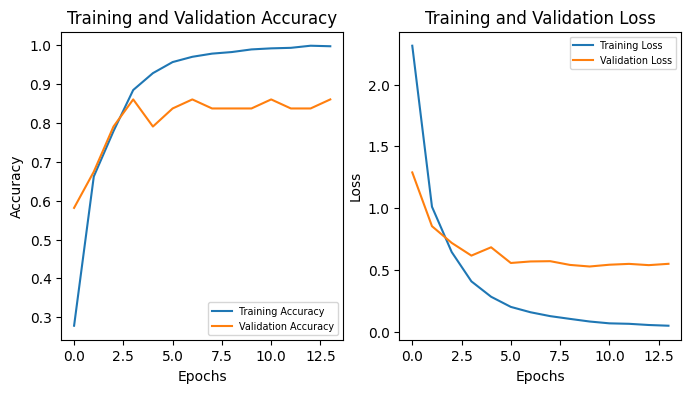

In [39]:
plot_training_history(history)


Test Metrics:
Accuracy: 0.4516

Macro-averaged metrics:
Precision: 0.4626
Recall: 0.4521
F1-score: 0.4455

Weighted-averaged metrics:
Precision: 0.4634
Recall: 0.4516
F1-score: 0.4455

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.50      0.52        16
           1       0.25      0.19      0.21        16
           2       0.62      0.62      0.62        16
           3       0.33      0.27      0.30        15
           4       0.45      0.62      0.53        16
           5       0.58      0.47      0.52        15
           6       0.29      0.47      0.36        15
           7       0.42      0.53      0.47        15
           8       0.57      0.25      0.35        16
           9       0.56      0.60      0.58        15

    accuracy                           0.45       155
   macro avg       0.46      0.45      0.45       155
weighted avg       0.46      0.45      0.45       155



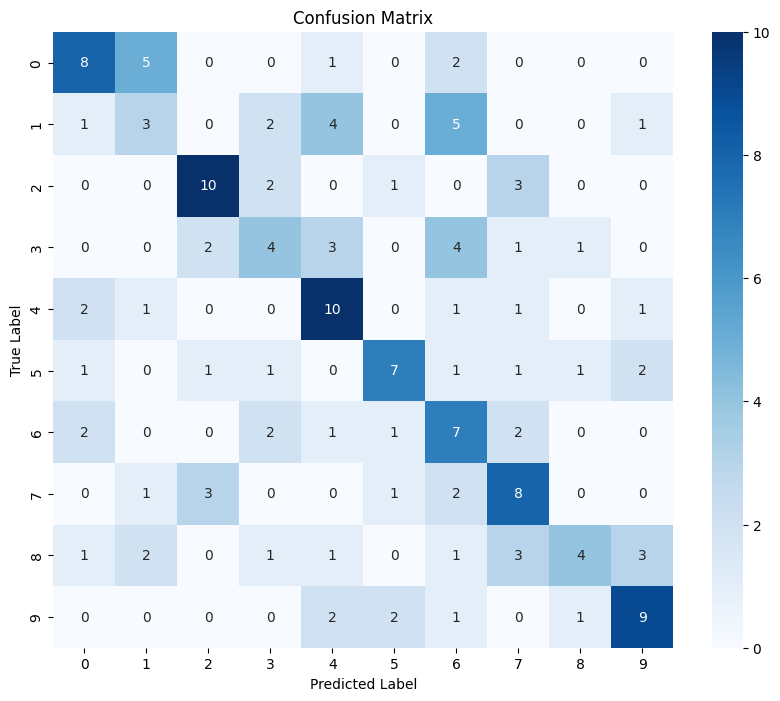

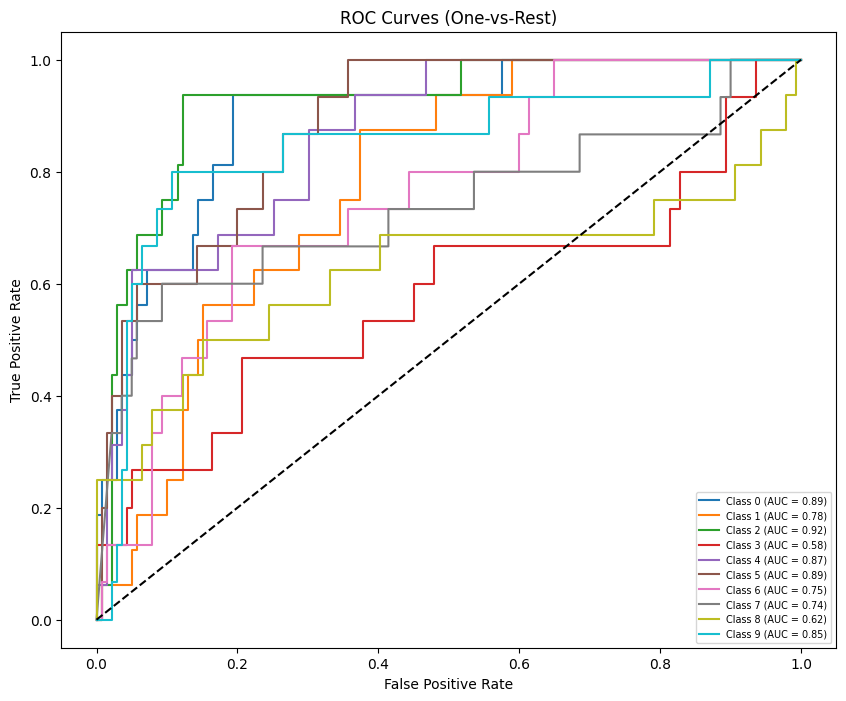

{'accuracy': 0.45161290322580644,
 'precision_macro': 0.462619332421964,
 'recall_macro': 0.4520833333333333,
 'f1_macro': 0.4454579193347599,
 'precision_weighted': 0.4634013369200126,
 'recall_weighted': 0.45161290322580644,
 'f1_weighted': 0.44547254531089014,
 'confusion_matrix': array([[ 8,  5,  0,  0,  1,  0,  2,  0,  0,  0],
        [ 1,  3,  0,  2,  4,  0,  5,  0,  0,  1],
        [ 0,  0, 10,  2,  0,  1,  0,  3,  0,  0],
        [ 0,  0,  2,  4,  3,  0,  4,  1,  1,  0],
        [ 2,  1,  0,  0, 10,  0,  1,  1,  0,  1],
        [ 1,  0,  1,  1,  0,  7,  1,  1,  1,  2],
        [ 2,  0,  0,  2,  1,  1,  7,  2,  0,  0],
        [ 0,  1,  3,  0,  0,  1,  2,  8,  0,  0],
        [ 1,  2,  0,  1,  1,  0,  1,  3,  4,  3],
        [ 0,  0,  0,  0,  2,  2,  1,  0,  1,  9]])}

In [40]:
calculate_multiclass_metrics(model=alexNetModel, test_ds=Test_scaled, num_classes=len(classNames))

Inception Net (Google Net)

In [ ]:
# Inception Net

# Res Net

In [ ]:
# Resnet-50

In [42]:
shutil.make_archive("/content/logs", 'zip', "logs")

'/content/logs.zip'